<a href="https://colab.research.google.com/github/me-pranjal-jha/CNN_LAB_RGIPT/blob/main/CNN_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import random
import numpy as np
import tensorflow as tf
import sys
import matplotlib
import pandas


random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("Installed package versions:")
print(f"Python      : {sys.version}")
print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Pandas      : {pandas.__version__}")

gpus = tf.config.list_physical_devices('GPU')

if len(gpus) > 0:
    print("\nGPU is available:")
    print(gpus)
else:
    print("\nNo GPU detected — running on CPU.")


Installed package versions:
Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow  : 2.19.0
NumPy       : 2.0.2
Matplotlib  : 3.10.0
Pandas      : 2.2.2

GPU is available:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


=== MNIST ===
Train images : (60000, 28, 28)
Train labels : (60000,)
Test images  : (10000, 28, 28)
Test labels  : (10000,)

=== CIFAR-10 ===
Train images : (50000, 32, 32, 3)
Train labels : (50000, 1)
Test images  : (10000, 32, 32, 3)
Test labels  : (10000, 1)

=== dtype and value range ===
MNIST   dtype = uint8, min = 0, max = 255
CIFAR-10 dtype = uint8, min = 0, max = 255

=== MNIST class distribution ===
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples

Minimum class count: 5421
Maximum class count: 6742
MNIST is approximately balanced.


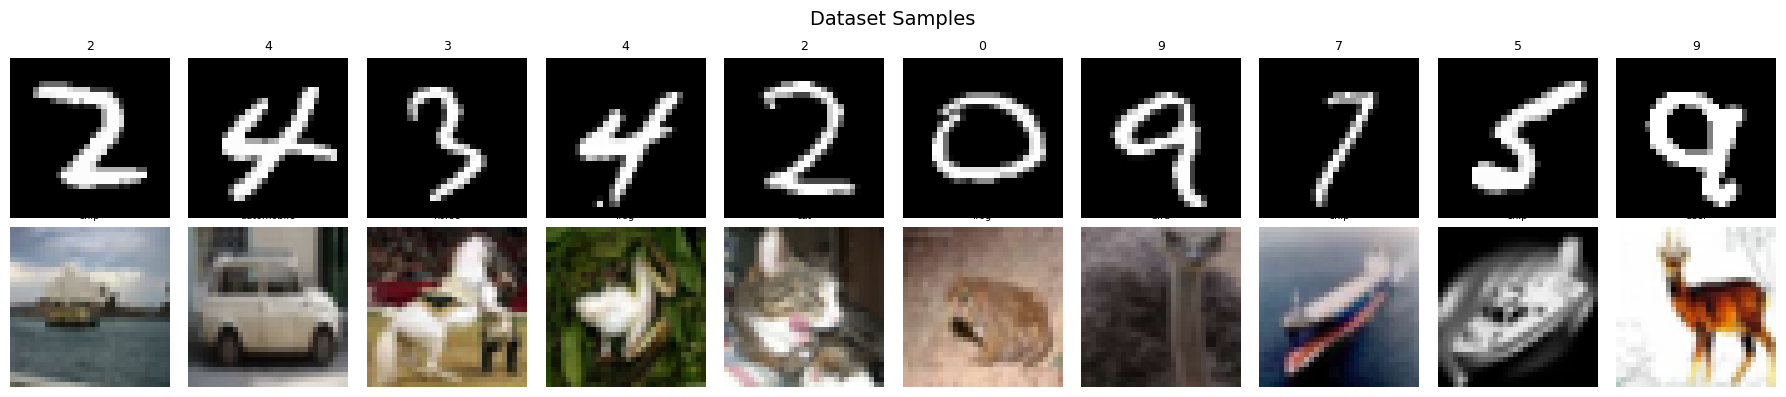

Saved dataset_samples.png


In [17]:
from tensorflow.keras.datasets import mnist, cifar10
import matplotlib.pyplot as plt
import numpy as np

(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = cifar10.load_data()

print("=== MNIST ===")
print(f"Train images : {mnist_x_train.shape}")
print(f"Train labels : {mnist_y_train.shape}")
print(f"Test images  : {mnist_x_test.shape}")
print(f"Test labels  : {mnist_y_test.shape}")

print("\n=== CIFAR-10 ===")
print(f"Train images : {cifar_x_train.shape}")
print(f"Train labels : {cifar_y_train.shape}")
print(f"Test images  : {cifar_x_test.shape}")
print(f"Test labels  : {cifar_y_test.shape}")

print("\n=== dtype and value range ===")
print(f"MNIST   dtype = {mnist_x_train.dtype}, min = {mnist_x_train.min()}, max = {mnist_x_train.max()}")
print(f"CIFAR-10 dtype = {cifar_x_train.dtype}, min = {cifar_x_train.min()}, max = {cifar_x_train.max()}")

print("\n=== MNIST class distribution ===")
unique, counts = np.unique(mnist_y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"Digit {cls}: {cnt} samples")

print(f"\nMinimum class count: {counts.min()}")
print(f"Maximum class count: {counts.max()}")
print("MNIST is approximately balanced.")

cifar_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

rng = np.random.default_rng(42)
mnist_idx = rng.choice(len(mnist_x_train), 10, replace=False)
cifar_idx = rng.choice(len(cifar_x_train), 10, replace=False)

fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Dataset Samples", fontsize=14)

for col, i in enumerate(mnist_idx):
    axes[0, col].imshow(mnist_x_train[i], cmap='gray')
    axes[0, col].set_title(str(mnist_y_train[i]), fontsize=9)
    axes[0, col].axis('off')

for col, i in enumerate(cifar_idx):
    axes[1, col].imshow(cifar_x_train[i])
    axes[1, col].set_title(cifar_names[cifar_y_train[i][0]], fontsize=7)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel("MNIST", fontsize=11)
axes[1, 0].set_ylabel("CIFAR-10", fontsize=11)

plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=120)
plt.show()

print("Saved dataset_samples.png")

In [18]:
def preprocess(images, labels, dataset_name='mnist'):
    print(f"\n--- {dataset_name} ---")
    print(f"Before normalise : shape={images.shape}, dtype={images.dtype}, "
          f"range=[{images.min()}, {images.max()}]")

    images = images.astype(np.float32) / 255.0
    print(f"After  normalise : shape={images.shape}, dtype={images.dtype}, "
          f"range=[{images.min():.2f}, {images.max():.2f}]")

    if dataset_name == 'mnist':
        images = images[..., np.newaxis]
        print(f"After  reshape   : shape={images.shape}")

    labels = labels.flatten()
    one_hot = np.zeros((len(labels), 10), dtype=np.float32)
    one_hot[np.arange(len(labels)), labels] = 1.0
    print(f"After  one-hot   : shape={one_hot.shape}, sample={one_hot[0]}")

    return images, one_hot


mnist_x_train_p, mnist_y_train_p = preprocess(mnist_x_train, mnist_y_train, 'mnist')
mnist_x_test_p,  mnist_y_test_p  = preprocess(mnist_x_test,  mnist_y_test,  'mnist')

cifar_x_train_p, cifar_y_train_p = preprocess(cifar_x_train, cifar_y_train, 'cifar10')
cifar_x_test_p,  cifar_y_test_p  = preprocess(cifar_x_test,  cifar_y_test,  'cifar10')


--- mnist ---
Before normalise : shape=(60000, 28, 28), dtype=uint8, range=[0, 255]
After  normalise : shape=(60000, 28, 28), dtype=float32, range=[0.00, 1.00]
After  reshape   : shape=(60000, 28, 28, 1)
After  one-hot   : shape=(60000, 10), sample=[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

--- mnist ---
Before normalise : shape=(10000, 28, 28), dtype=uint8, range=[0, 255]
After  normalise : shape=(10000, 28, 28), dtype=float32, range=[0.00, 1.00]
After  reshape   : shape=(10000, 28, 28, 1)
After  one-hot   : shape=(10000, 10), sample=[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]

--- cifar10 ---
Before normalise : shape=(50000, 32, 32, 3), dtype=uint8, range=[0, 255]
After  normalise : shape=(50000, 32, 32, 3), dtype=float32, range=[0.00, 1.00]
After  one-hot   : shape=(50000, 10), sample=[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

--- cifar10 ---
Before normalise : shape=(10000, 32, 32, 3), dtype=uint8, range=[0, 255]
After  normalise : shape=(10000, 32, 32, 3), dtype=float32, range=[0.00, 1.00]
After  one-hot   : sh

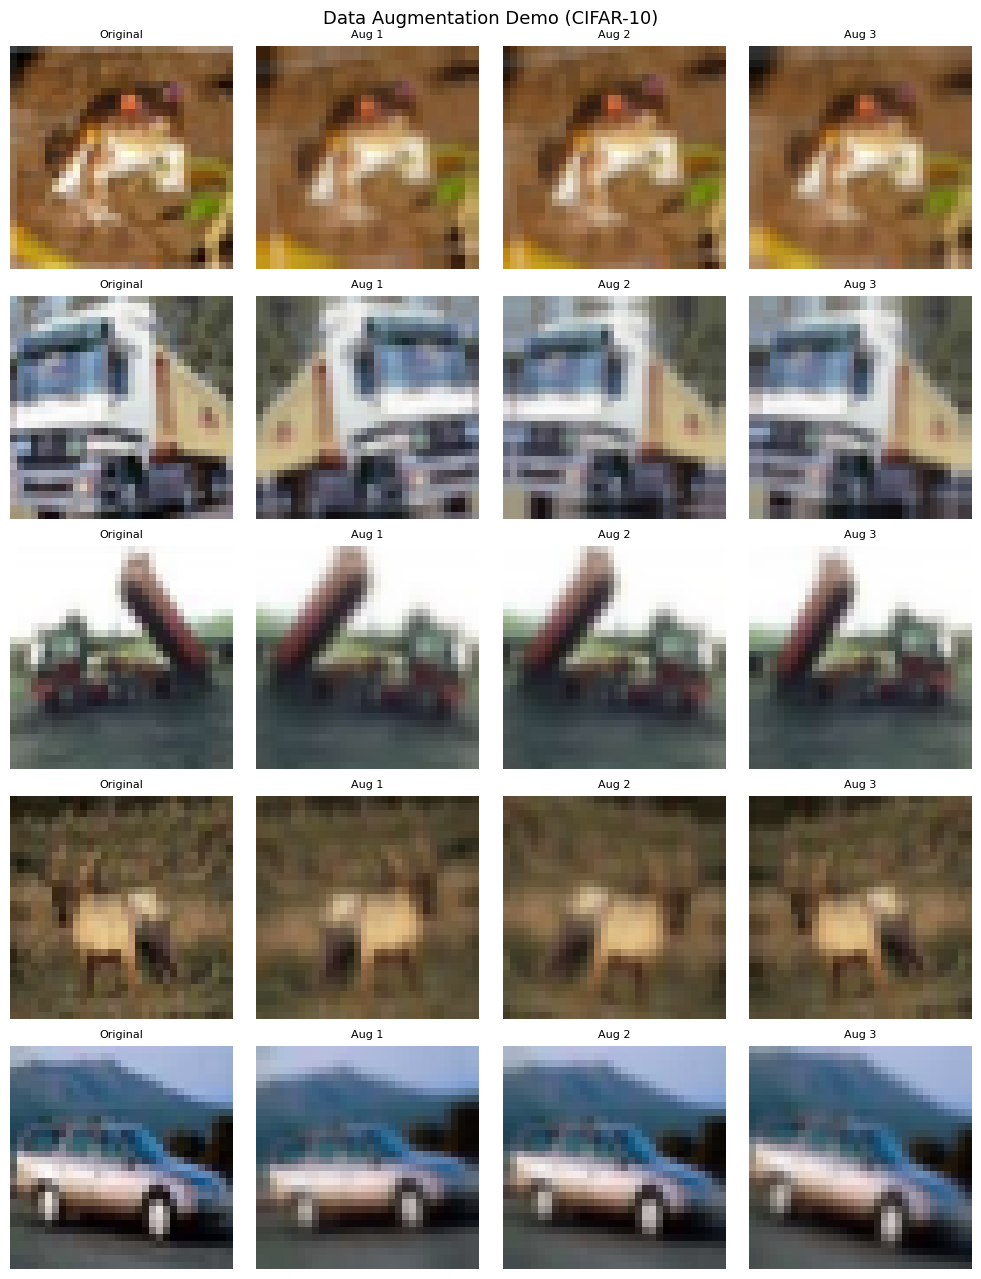

Saved augmentation_demo.png


In [19]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(10/360),
    layers.RandomZoom(0.1),
], name='augmentation')

sample_imgs = cifar_x_train_p[:5]

fig, axes = plt.subplots(5, 4, figsize=(10, 13))
fig.suptitle('Data Augmentation Demo (CIFAR-10)', fontsize=13)

for row in range(5):
    img = sample_imgs[row:row+1]
    axes[row, 0].imshow(sample_imgs[row])
    axes[row, 0].set_title('Original', fontsize=8)
    axes[row, 0].axis('off')
    for col in range(1, 4):
        aug = data_augmentation(img, training=True)[0].numpy()
        aug = np.clip(aug, 0, 1)
        axes[row, col].imshow(aug)
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_demo.png', dpi=120)
plt.show()

print('Saved augmentation_demo.png')

### Justification — Augmentation on Training Set Only

Data augmentation is applied only to the training set because its purpose is to artificially increase the diversity of the training data and help the model generalise better. By introducing variations such as flips, rotations, and zoom, the model learns to be invariant to these changes.

If augmentation is applied to the validation or test set, it would alter the original data distribution. This makes evaluation unreliable because the model is no longer being tested on real, unmodified data. Additionally, augmented data introduces randomness, which makes the evaluation non-deterministic and not reproducible. Therefore, augmentation must be restricted to the training set only.

---

### Q1. Channel Dimension in (N, H, W, C)

In a tensor of shape (N, H, W, C), the channel dimension C represents the number of features or colour channels present at each pixel location.

For a grayscale image, C = 1, meaning each pixel contains only one intensity value representing brightness. For an RGB image, C = 3, where each pixel contains three values corresponding to red, green, and blue colour intensities.

In convolutional neural networks, filters operate across all channels simultaneously. Each filter has separate weights for each channel, and the outputs are combined to produce a single feature map. This allows the network to capture both spatial and colour-based patterns.

---

### Q2. Handling Large Images (1024×1024)

When working with very large images like 1024×1024, loading the entire dataset into memory can cause out-of-memory (OOM) errors. Two effective strategies to handle this are:

1. **Using tf.data with batching and prefetching**  
   Instead of loading all data at once, images are loaded in small batches during training. The `tf.data.Dataset` pipeline allows efficient streaming of data from disk, and prefetching overlaps data loading with computation, improving performance and reducing memory usage.

2. **Patch-based training**  
   Large images can be divided into smaller patches (for example, 256×256), and the model is trained on these patches instead of the full image. This significantly reduces memory requirements while still allowing the model to learn local features. Over time, the model sees different parts of the image and learns the overall distribution.

---

### Q3. Problem with Normalising Using Test Set Statistics

Normalising the test set using its own mean and standard deviation leads to data leakage. This means that information from the test data is being used during preprocessing, which should not happen because the test set is meant to represent completely unseen data.

As a result, the model evaluation becomes biased and overly optimistic, since it indirectly benefits from knowledge of the test data distribution. It also reduces reproducibility, as the statistics would change if the test set changes.

The correct approach is to compute normalisation parameters (mean and standard deviation) using only the training set, and then apply those same values to both the validation and test sets.

In [20]:
def conv2d(image, kernel, stride=1, padding=0):
    """2D convolution using only NumPy — no external conv utilities."""
    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    ih, iw = image.shape
    kh, kw = kernel.shape

    out_h = (ih - kh) // stride + 1
    out_w = (iw - kw) // stride + 1
    output = np.zeros((out_h, out_w), dtype=np.float64)

    for r in range(out_h):
        for c in range(out_w):
            patch = image[r*stride : r*stride+kh, c*stride : c*stride+kw]
            output[r, c] = np.sum(patch * kernel)

    return output

# ─── Test ─────────────────────────────────────────────────────────────────────
test_image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
], dtype=np.float64)

sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float64)

result = conv2d(test_image, sobel_x, stride=1, padding=0)

print("Feature map output:")
print(result)

# Manual shape verification: floor((5-3+2*0)/1)+1 = 3
expected_shape = ((5 - 3 + 2*0) // 1 + 1, (5 - 3 + 2*0) // 1 + 1)
print(f"\nOutput shape : {result.shape}  (expected {expected_shape})")

Feature map output:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output shape : (3, 3)  (expected (3, 3))


## Problem 2 — Output Size Derivation

Formula: `Output = floor((Input - Kernel + 2×Padding) / Stride) + 1`

**(a)** Input=28, K=5, P=0, S=1  
`floor((28 - 5 + 0) / 1) + 1 = 23 + 1 = **24×24**`

**(b)** Input=28, K=3, P=1, S=1  
`floor((28 - 3 + 2) / 1) + 1 = 27 + 1 = **28×28**`  *("same" padding preserves spatial size)*

**(c)** Input=32, K=3, P=0, S=2  
`floor((32 - 3 + 0) / 2) + 1 = floor(29/2) + 1 = 14 + 1 = **15×15**`

**(d)** Two consecutive layers on 32×32:  
Layer 1: K=3, P=1, S=1 → `floor((32-3+2)/1)+1 = 32` → **32×32**  
Layer 2: K=3, P=0, S=1 → `floor((32-3+0)/1)+1 = 30` → **30×30**

In [21]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, AveragePooling2D, Flatten, Dense, Activation
)

def build_lenet5():
    model = Sequential([
        # Block 1
        Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)),
        Activation('tanh'),
        AveragePooling2D(pool_size=(2,2), strides=2),
        # Block 2
        Conv2D(16, (5,5), padding='valid'),
        Activation('tanh'),
        AveragePooling2D(pool_size=(2,2), strides=2),
        # Classifier
        Flatten(),
        Dense(120), Activation('tanh'),
        Dense(84),  Activation('tanh'),
        Dense(10,   activation='softmax'),
    ], name='LeNet-5')
    return model

lenet = build_lenet5()
lenet.summary()

# ─── Manual param count for first Conv2D ──────────────────────────────────────
# Formula: (K_H × K_W × C_in + 1) × C_out
# = (5 × 5 × 1 + 1) × 6 = 26 × 6 = 156
manual = (5*5*1 + 1) * 6
print(f"\nManual param count (Conv2D-1): ({5}×{5}×{1}+1)×{6} = {manual}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


Manual param count (Conv2D-1): (5×5×1+1)×6 = 156


**Why AvgPool in LeNet-5 vs MaxPool today?**  
LeCun's 1998 paper used average pooling because it was theoretically motivated by
sub-sampling and computing local averages kept gradient flow smooth. MaxPooling is
preferred today because it retains the strongest (most activated) feature in each
window, providing better translation invariance and sharper feature detection.
Empirically MaxPooling leads to faster convergence and higher accuracy on modern
benchmarks.

## Problem 4 — Custom CNN for CIFAR-10

**Architecture sketch:**
```
Input (32×32×3)
  │
  ├─ Block 1: Conv2D(32, 3×3) → BN → ReLU → MaxPool(2×2)  → 16×16×32
  ├─ Block 2: Conv2D(64, 3×3) → BN → ReLU → MaxPool(2×2)  →  8×8×64
  ├─ Block 3: Conv2D(128,3×3) → BN → ReLU → MaxPool(2×2)  →  4×4×128
  │
  ├─ GlobalAveragePooling2D                                →  128
  ├─ Dense(256) → ReLU → Dropout(0.4)
  └─ Dense(10)  → Softmax
```

**Design rationale (3–4 sentences):**  
Three convolutional blocks with doubling filter counts (32→64→128) allow the network
to learn progressively more abstract representations. Batch Normalisation after each
Conv2D stabilises training and reduces internal covariate shift, allowing a higher
learning rate. GlobalAveragePooling collapses the spatial map to a single vector per
filter, drastically reducing parameters vs Flatten and acting as a spatial regulariser.
Dropout(0.4) in the dense head prevents co-adaptation of neurons and reduces
overfitting on the relatively small CIFAR-10 training set.

In [22]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation,
    MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
)
from tensorflow.keras import Model

def build_custom_cnn(input_shape=(32,32,3), num_classes=10):
    inputs = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Block 2
    x = Conv2D(64, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Block 3
    x = Conv2D(128, (3,3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='Custom_CIFAR_CNN')

custom_cnn = build_custom_cnn()
custom_cnn.summary()

Model: "Custom_CIFAR_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

## Analysis Q1–Q3 (Task 2)

**Q1. Two 3×3 vs one 5×5 (same number of filters F):**  
Params for two 3×3 layers: `2 × (3×3×F + 1)×F ≈ 18F²`  
Params for one 5×5 layer: `(5×5×F + 1)×F ≈ 25F²`  
Two 3×3 layers use ~28% fewer parameters. They also provide two non-linearities
instead of one, richer feature extraction, and the same 5×5 effective receptive
field.

**Q2. Batch Normalisation:**  
BatchNorm normalises each mini-batch's activations to zero mean and unit variance,
then applies learnable scale γ and shift β. It is typically placed after Conv2D and
before the activation (though post-activation also works). Empirical benefits:
(1) allows higher learning rates without divergence; (2) acts as a mild regulariser,
often reducing the need for Dropout; (3) smooths the loss landscape, leading to
faster convergence.

**Q3. GlobalAveragePooling vs Flatten:**  
GAP computes the spatial mean of each feature map, collapsing (H, W, C) → (C,).
This removes all spatial information. Replacing GAP with Flatten would turn each
4×4×128 tensor into a 2048-dim vector, adding `(2048+1)×256 ≈ 524,544` extra
parameters to the first Dense layer alone, massively increasing overfitting risk
and memory cost.